### Bayesian Inference(Bayes çıxarışı). Naive Bayes Classifier

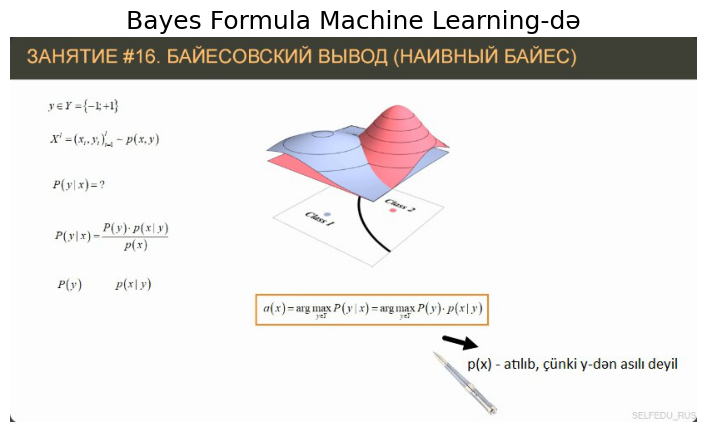

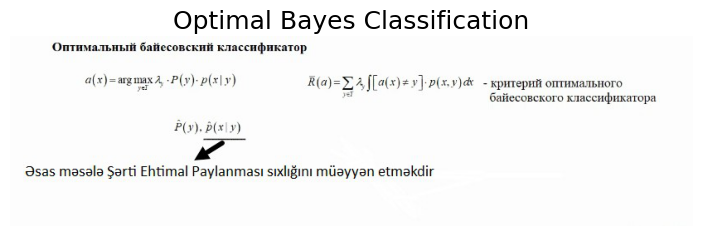

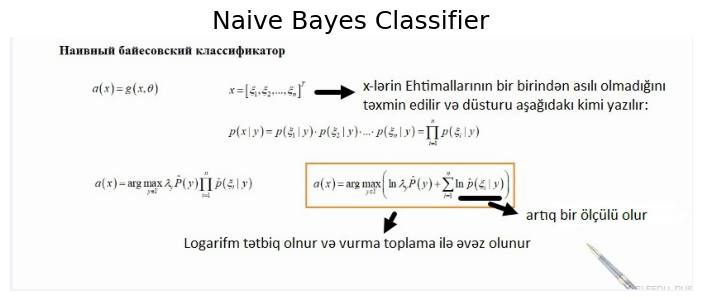

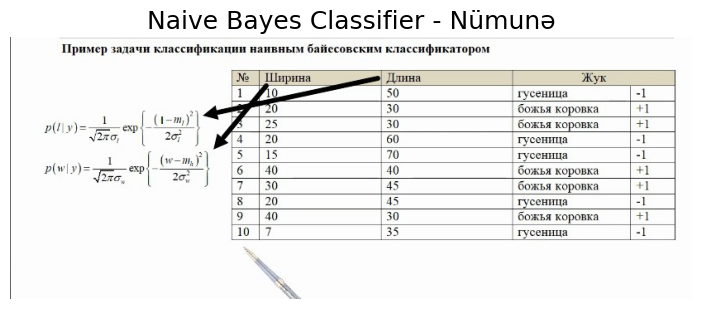

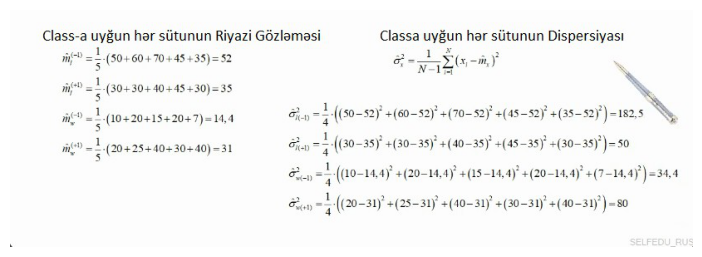

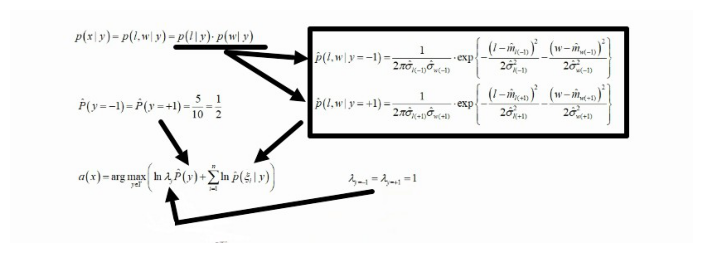

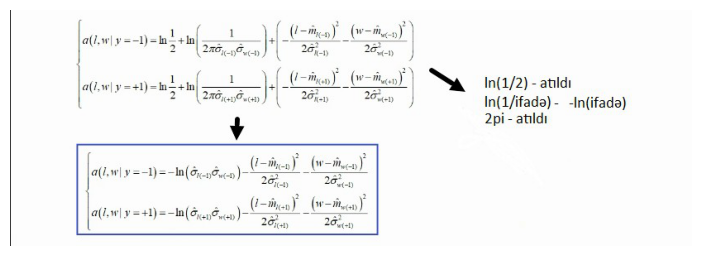

In [55]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_16_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 8):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 1:
        plt.figure(figsize=(8.8, 4))
    elif i == 2:
        plt.figure(figsize=(8.8, 4))
    elif i == 3:
        plt.figure(figsize=(8.8, 4))
    elif i == 4:
        plt.figure(figsize=(8.8, 4))
    elif i == 5:
        plt.figure(figsize=(8.8, 4))
    elif i == 6:
        plt.figure(figsize=(8.8, 4))         
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""Bayes Formula Machine Learning-də""", size='18') 
    elif i < 2:
        plt.title("""Optimal Bayes Classification""", size='18') 
    elif i < 3:
        plt.title("""Naive Bayes Classifier""", size='18')
    elif i < 4:
        plt.title("""Naive Bayes Classifier - Nümunə""", size='18')
    elif i < 5:
        plt.title("""""", size='18')
    elif i < 6:
        plt.title("""""", size='18')
    elif i < 7:
        plt.title("""""", size='18')         
        

    
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### Bayes Formula Machine Learning-də

**Bayes teoremi:**

$$
P(y|x) = \frac{P(y) \cdot p(x|y)}{p(x)}
$$

Bunu belə izah edə bilərik:

1. **$P(y|x)$** – **Posterior ehtimalı**. **Bu, $x$ xüsusiyyətlərini gördükdən sonra $y$ sinifinə aid olma Ehtimalıdır.**

2. **$P(y)$** – **Prior ehtimalı**. **Bu, siniflərin əvvəldən məlum ehtimalıdır, yəni x-yə baxmadan əvvəl $y$ sinifinin Ehtimalı.**

3. **$p(x|y)$** – **Likelihood (mövcudluq ehtimalı)**. **Bu, hansı$(-1; +1)$ $y$ sinifinə aid olduğunu bildiyimiz halda $x$ xüsusiyyətlərinin Ehtimal paylanmasıdır**

4. **$p(x)$** – **Evidence (substantiv ehtimal)**. **Bu, $x$ xüsusiyyətlərinin bütün siniflər üzrə ümumi ehtimalıdır, yəni $x$-in bu və ya digər sinfə aid olub-olmamasından asılı olmayaraq Ehtimal paylanması.**


$$$$

#### 🔹 p(x)-in açılışı nədir?

$ p(x) $ — bütün siniflər üzrə ümumi ehtimaldır.
Bu **Total Probability (Tam ehtimal qanunu)** ilə hesablanır:

$$
p(x) = \sum_{y \in \mathcal{Y}} P(y) \ p(x|y)
$$

Əgər 2 sinif varsa (məsələn $ y \in {-1, +1} $):

$$
p(x) = P(y=-1) \ p(x|y=-1) + P(y=+1) \ p(x|y=+1)
$$

Yəni:

👉 x-in ümumi ehtimalı = hər sinif üçün (prior × likelihood) cəmi

$$$$

#### 🔹 Bəs p(x) doğrudan da y-dən asılı deyil?

Əsas məsələ budur:

* $ p(x) $ hesablanarkən **bütün y-lər üzrə cəmlənir**
* Nəticədə konkret bir y qalmır

Yəni:

$$
p(x) = \sum_y P(y) \ p(x|y)
$$

Bu ifadədə artıq **y yoxdur**, çünki biz onu cəmləmişik.

Ona görə də:

$$
a(x) = argmax_y \frac{P(y) \ p(x|y)}{p(x)}
$$

burada $ p(x) $ bütün y-lər üçün eyni sabitdir.

Sabit olduğu üçün argmax-a təsir etmir və atılır:

$$
a(x) = argmax_y \ P(y)\ p(x|y)
$$



#### 🔹 Intuitiv izah

$p(x)$ sadəcə "normalizasiya sabiti"dir.

O yalnız ehtimalların cəmini 1 etmək üçündür.
Hansının daha böyük olduğunu dəyişmir.

Məsələn:

$$
\frac{5}{20} > \frac{3}{20}
$$

20 hər ikisində eyni olduğu üçün müqayisəyə təsir etmir.



#### 🔹 Qısa cavab

* $p(x)$ = bütün siniflər üzrə prior × likelihood cəmi
* Hesablanarkən y istifadə olunur
* Amma nəticədə y qalmaz
* Ona görə classification-da atılır

$$$$

Başqa sözlə, Bayes teoremi bizə deyir:

> **Əgər əvvəldən siniflər haqqında məlumatımız $(P(y))$ və hər sinifdə xüsusiyyətlərin paylanmasını $(P(x|y))$ bilsək, $x$ müşahidə etdikdən sonra (y) sinifinə aid olma ehtimalını $(P(y|x))$ hesablaya bilərik.**

$$
 Model \ Classification:
$$

$$
a(x) = \arg \max_{y \in \mathbb{Y}} P(y \mid x) = \arg \max_{y \in \mathbb{Y}} P(y) \cdot p(x \mid y)
$$

- **$p(x)$ atılıb çünki y-dən asılı deyil**

### Python dilində - Naive Bayes Classifier Nümunəsi

In [56]:
# Numpy kitabxanasını riyazi hesablamalar və massiv (array) əməliyyatları üçün import edirik
import numpy as np

# Təlim datasını (xüsusiyyətlər: məsələn, en və uzunluq) 2 ölçülü numpy massivi kimi yaradırıq
x_train = np.array([[10, 50], [20, 30], [25, 30], [20, 60], [15, 70], [40, 40], [30, 45], [20, 45], [40, 30], [7, 35]])
# Hər müşahidəyə uyğun sinif etiketlərini (-1 və 1) 1 ölçülü massiv kimi təyin edirik
y_train = np.array([-1, 1, 1, -1, -1, 1, 1, -1, 1, -1])

# y=1 olan müşahidələr üçün hər iki xüsusiyyət üzrə (sütunlara görə) orta qiyməti hesablayırıq
mw1, ml1 = np.mean(x_train[y_train == 1], axis=0)
# y=-1 olan müşahidələr üçün hər iki xüsusiyyət üzrə orta qiyməti hesablayırıq
mw_1, ml_1 = np.mean(x_train[y_train == -1], axis=0)

# y=1 sinfi üçün hər xüsusiyyət üzrə seçmə dispersiyanı (ddof=1 → 1/(N-1)) hesablayırıq
sw1, sl1 = np.var(x_train[y_train == 1], axis=0, ddof=1)
# y=-1 sinfi üçün hər xüsusiyyət üzrə seçmə dispersiyanı hesablayırıq
sw_1, sl_1 = np.var(x_train[y_train == -1], axis=0, ddof=1)

# Hər iki sinif üçün hesablanmış riyazi gözləmə (mean) dəyərlərini çap edirik
print('МО: ', mw1, ml1, mw_1, ml_1)
# Hər iki sinif üçün hesablanmış dispersiya dəyərlərini çap edirik
print('Дисперсии:', sw1, sl1, sw_1, sl_1)

# Təsnif etmək istədiyimiz yeni obyektin xüsusiyyətlərini (məsələn, en və uzunluq) daxil edirik
x = [10, 40]  # ширина, длина жука

# -1 sinfi üçün Gauss paylanmasına əsaslanan log-ehtimal funksiyasını (Naive Bayes diskriminant funksiyası) təyin edirik
a_1 = lambda x: -np.log(np.sqrt(sw_1) * np.sqrt(sl_1)) - (x[0] - mw_1) ** 2 / (2 * sw_1) - (x[1] - ml_1) ** 2 / (2 * sl_1)
print(f"Düsturun nəticəsi - a_1: {a_1(x)}")
# 1 sinfi üçün eyni qaydada Gauss əsaslı log-ehtimal funksiyasını təyin edirik
a1 = lambda x: -np.log(np.sqrt(sw1) * np.sqrt(sl1)) - (x[0] - mw1) ** 2 / (2 * sw1) - (x[1] - ml1) ** 2 / (2 * sl1)
print(f"Düsturun nəticəsi - a1: {a1(x)}")
      
# Hər iki sinif üçün diskriminant dəyərləri müqayisə edib maksimum olanı seçərək nəticəni -1 və ya 1 kimi qaytarırıq:
# argmax - maksimum dəyərin indeksini qaytarır - bu halda iki element var - ya 0, ya 1 qaytaracaq
# 2-ə vurub 1 çıxanda da ya -1, ya da 1 qaytaracaq 
y = np.argmax([a_1(x), a1(x)]) * 2 - 1 
# Proqnozlaşdırılan sinfi çap edirik (-1: tırtıl, 1: uğur böcəyi kimi şərh olunur)
print("""Maksimum olanı seçilib argmax-ın köməyi ilə Class(-1, 1) kimi aytarıldı:
Номер класса (-1 - гусеница, 1 - божья коровка): """, y)

# Təlim datası üzərində modelin səhv nisbətini yoxlamaq üçün boş siyahı yaradırıq
pr = []
# Təlim datasındakı hər müşahidə üçün sinif proqnozu hesablayırıq
for x in x_train:
    pr.append(np.argmax([a_1(x), a1(x)]) * 2 - 1)

# Proqnoz siyahısını numpy massivinə çeviririk
pr = np.array(pr)

# Proqnoz ilə real etiket fərqli olduqda 1 sayaraq orta səhv payını (error rate) hesablayırıq
Q = np.mean(pr != y_train)
# Modelin səhv nisbətini (error rate) çap edirik
print(f"Lost: {Q}")

МО:  31.0 35.0 14.4 52.0
Дисперсии: 80.0 50.0 34.3 182.5
Düsturun nəticəsi - a_1: -5.04768405498266
Düsturun nəticəsi - a1: -7.1532748200510134
Maksimum olanı seçilib argmax-ın köməyi ilə Class(-1, 1) kimi aytarıldı:
Номер класса (-1 - гусеница, 1 - божья коровка):  -1
Lost: 0.0


### Python - Scikit-learn - Naive Bayes modeli


`scikit-learn`-də **Naive Bayes** modeli:

* ❌ **Gradient descent istifadə etmir**
* ❌ **Loss function optimallaşdırmır**
* ❌ **ω (weight) kimi parametr öyrənmir**
* ✔ **Sadəcə ehtimal parametrlərini statistik olaraq hesablayır**

---

#### 1️⃣ `fit()` zamanı nə baş verir?

`scikit-learn`-də Naive Bayes `fit()` zamanı bu parametrləri hesablayır.

#### Prior

$$
P(y)
$$

$$
P(y)=\frac{\text{sinifdəki nümunə sayı}}{\text{ümumi nümunə sayı}}
$$

$$$$

#### Likelihood parametrləri

Model növündən asılıdır.

#### GaussianNB

$$
\mu_y , \quad \Sigma_y
$$

hesablanır:

$$
\mu_y = \frac{1}{n_y}\sum x_i
$$

$$
\sigma_y^2 = \frac{1}{n_y}\sum (x_i-\mu_y)^2
$$

Yəni **mean və variance**.

$$$$

#### MultinomialNB

$$
P(x_j|y)
$$

word count və ya feature count əsasında hesablanır.

$$$$

#### BernoulliNB

$$
P(x_j=1|y)
$$

binary feature ehtimalları.

---

#### 2️⃣ `predict()` necə işləyir?

Model hər sinif üçün bu skoru hesablayır:

$$
score_y = \log P(y) + \sum \log P(x_i|y)
$$

Sonra:

$$
\hat y = argmax_y(score_y)
$$

$$$$

Python-da:

```python
model.predict(X)
```

daxildə bu hesablanır.

---

#### 3️⃣ `predict_proba()`

Posterior ehtimal qaytarır:

$$
P(y|x)
$$

Python:

```python
model.predict_proba(X)
```

---

#### 4️⃣ Loss function varmı?

❌ **Xeyr**

Naive Bayes:

* optimization problemi deyil
* **closed-form estimation** istifadə edir.

Sadəcə ehtimal parametrlərini hesablayır.

---

#### 5️⃣ Gradient descent varmı?

❌ **Yox**

Bu modellərdə var:

* Logistic Regression
* Neural Networks
* SVM (soft margin)

Amma **Naive Bayes**:

$$
\text{statistical estimation}
$$

edir.

---

#### 6️⃣ ω (omega) varmı?

Naive Bayes-də **ω parametr yoxdur**.

Sənin gördüyün ω:

* Logistic Regression
* SVM
* Linear models

üçündür.

Naive Bayes isə:

$$
P(y), P(x|y)
$$

öyrənir.

---

#### 7️⃣ Scikit-learn-də real pipeline

```python
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

#### `fit()` nəticəsində saxlanılan parametrlər

```python
model.class_prior_
model.theta_      # mean
model.var_        # variance
```

---

#### 8️⃣ Qısa müqayisə

| Model               | Loss       | Gradient | Parametr       |
| ------------------- | ---------- | -------- | -------------- |
| Naive Bayes         | ❌ yoxdur   | ❌ yoxdur | mean, variance |
| Logistic Regression | log-loss   | ✔ var    | ω              |
| SVM                 | hinge loss | ✔ var    | ω              |

---

✅ **Bir cümlə ilə**

**Scikit-learn Naive Bayes sadəcə statistik olaraq prior və likelihood parametrlərini hesablayır və `argmax P(y)P(x|y)` qaydası ilə sinif seçir.**


#### Naive Bayes-in **`scikit-learn` daxilində `predict()` necə işləyir** – bunu riyazi olaraq **addım-addım** göstərək.

- Scikit-learn-də **Naive Bayes** nəzəriyyədə yazdığın Bayes düsturunun **birbaşa statistik hesablanmasıdır**.
- Burada **gradient descent, loss minimization və ya weight (ω)** öyrənilməsi **yoxdur**.
- Çünki bu **generative model**-dir.
- Burada əsasən **Gaussian Naive Bayes** modelinə baxacağıq (`GaussianNB`).

$$$$

#### 1️⃣ Scikit-learn Naive Bayes necə öyrənir (fit)

$$$$

- `fit()` zamanı model sadəcə **bu statistik parametrləri hesablayır**.

$$$$

#### Addım 1 — Prior ehtimalı

$$
P(y)=\frac{N_y}{N}
$$

* $N_y$ → həmin sinifdəki nümunə sayı
* $N$ → ümumi nümunə sayı

$$$$

#### Addım 2 — Likelihood parametrləri

Model növündən asılıdır.

$$$$

#### GaussianNB

Hər sinif üçün:

$$
\mu_y = mean(X_y)
$$

$$
\sigma_y^2 = var(X_y)
$$

yəni:

* **mean**
* **variance**

hesablanır.


$$$$

#### Mean

$$
\mu_{y,j}=\frac{1}{N_y}\sum_{i:y_i=y} x_{ij}
$$

* $j$ → feature nömrəsi
* $x_{ij}$ → i-ci nümunənin j-ci xüsusiyyəti

$$$$

#### Variance

$$
\sigma_{y,j}^2=\frac{1}{N_y}\sum_{i:y_i=y}(x_{ij}-\mu_{y,j})^2
$$

$$$$

#### Modeldə saxlanır

`scikit-learn` daxilində:

```python
model.class_prior_
model.theta_   # mean
model.var_     # variance
```





$$$$

#### MultinomialNB

$$
P(x_i|y)=\frac{count(x_i,y)+\alpha}{\sum_j count(x_j,y)+\alpha n}
$$

* word count əsaslı
* Laplace smoothing istifadə edilir.

$$$$

#### BernoulliNB

$$
P(x_i=1|y)
$$

binary feature üçün ehtimal hesablanır.


---

$$$$


#### 2️⃣ Predict necə işləyir

$$$$

#### Bayes qərarı

Bayes teoremi:

$$
P(y|x)=\frac{P(y) \ p(x|y)}{p(x)}
$$

classification üçün:

$$
\hat y = argmax_y P(y) \  p(x|y)
$$


`predict()` bu düsturu hesablayır.

$$
P(y|x) \propto P(y) \ P(x|y)
$$

> amma **log-space** istifadə edir.

$$$$
#### Real implementasiya - Log-space keçidi

`scikit-learn` overflow olmaması üçün **log istifadə edir**.

$$
\log P(y|x) = \log P(y) + \log P(x|y)
$$

$$$$

#### Predict zamanı likelihood hesablanır

**Gaussian Naive Bayes-dir üçün:**


$$
p(x_j|y)=\frac{1}{\sqrt{2\pi\sigma_{y,j}^2}}
\exp\left(-\frac{(x_j-\mu_{y,j})^2}{2\sigma_{y,j}^2}\right)
$$

- **Gaussian log formu:**

$$
\log p(x_j|y) =
-\frac{1}{2}\log(2\pi\sigma_{y,j}^2)
-\frac{(x_j-\mu_{y,j})^2}{2\sigma_{y,j}^2}
$$

- Naive Bayes fərz edir ki **feature-lər müstəqildir**.

Ona görə:

$$
p(x|y)=\prod_{j=1}^{n} p(x_j|y)
$$


- **Bütün feature-lər üzrə cəm**

$$
score_y =
\log P(y)
-\frac{1}{2}\sum_{j=1}^{n}\log(2\pi\sigma_{y,j}^2)
-\frac{1}{2}\sum_{j=1}^{n}\frac{(x_j-\mu_{y,j})^2}{\sigma_{y,j}^2}
$$


$$$$

**Gaussian Multivariate Gaussian paylanması üçün:**

$$
\log P(x|y) = - \frac{1}{2}(x-\mu_y)^T\Sigma_y^{-1}(x-\mu_y) - \frac{1}{2}\log |\Sigma_y|
$$




---

#### 3️⃣ Predict_proba necə işləyir

Əvvəl:

$$
score_y = \log P(y) + \log P(x|y)
$$

sonra:

$$
P(y|x)=\frac{e^{score_y}}{\sum_j e^{score_j}}
$$

yəni **softmax**. 

---

#### 4️⃣ `predict()` qərarı

Model hər sinif üçün bu **score** hesablayır:

$$
score_y
$$

sonra:

$$
\hat y = argmax_y(score_y)
$$

---

#### 5️⃣ `scikit-learn` kod məntiqi

Daxildə təxminən belə işləyir.

```python
joint_log_likelihood = []

for each class y:

    log_prior = log(P(y))

    log_likelihood =
    -0.5 * sum(log(2π * var_y))
    -0.5 * sum((x - mean_y)^2 / var_y)

    score = log_prior + log_likelihood

choose class with max(score)
```

---

#### 1️⃣1️⃣ Scikit-learn-də loss funksiyası varmı?

Naive Bayes:

- ❌ loss minimization etmir
- ❌ gradient descent istifadə etmir
- ❌ weight vector yoxdur
- Sadəcə **Maximum Likelihood Estimation (MLE)** istifadə edir.

Sadəcə:

$$
\mu,\sigma^2,P(y)
$$

hesablayır.

---

#### 1️⃣2️⃣ SVM və Logistic Regression ilə fərq

| Model               | necə öyrənir         |
| ------------------- | -------------------- |
| Naive Bayes         | statistik estimation |
| Logistic Regression | gradient descent     |
| SVM                 | optimization problem |

---

✅ **Qısa cavab**

Scikit-learn Naive Bayes:

* loss funksiyası yoxdur
* gradient descent yoxdur
* weight öyrənmir
* `fit()` zamanı **mean, variance, prior** hesablayır
* `predict()` zamanı

$$
argmax_y \log P(y) + \log P(x|y)
$$


✅ **Bir cümlə ilə**

`scikit-learn GaussianNB predict()` funksiyası **log prior + Gaussian log likelihood** hesablayır və **ən böyük score olan sinfi seçir.**


#### Naive Bayes və Logistic Regression çox vaxt eyni tip qərar sərhədi (decision boundary) verir

- Bunun səbəbini riyazi olaraq sadə formada izah edək.


#### 1️⃣ Bayes classifier qərar qaydası

Naive Bayes qərarı:

$$
\hat y = argmax_y P(y|x)
$$

Bayes teoremi:

$$
P(y|x) \propto P(y) \ p(x|y)
$$

ona görə:

$$
\hat y = argmax_y P(y) \ p(x|y)
$$

---

#### 2️⃣ İki sinif üçün (y ∈ {0,1})

Model 1 sinfini seçir əgər:

$$
P(y=1)p(x|y=1) > P(y=0)p(x|y=0)
$$

Log götürək:

$$
\log P(y=1) + \log p(x|1) >
\log P(y=0) + \log p(x|0)
$$

---

#### 3️⃣ Gaussian likelihood yazırıq

Gaussian NB üçün:

$$
p(x_j|y)=
\frac{1}{\sqrt{2\pi\sigma_{y,j}^2}}
\exp\left(
-\frac{(x_j-\mu_{y,j})^2}{2\sigma_{y,j}^2}
\right)
$$

---

#### 4️⃣ Log likelihood

$$
\log p(x_j|y)=
-\frac{1}{2}\log(2\pi\sigma_{y,j}^2) - \frac{(x_j-\mu_{y,j})^2}{2\sigma_{y,j}^2}
$$

---

#### 5️⃣ Əgər variances eynidirsə

Çox istifadə olunan sadə model:

$$
\sigma_{1,j}^2 = \sigma_{0,j}^2
$$

bu halda kvadratları açsaq:

$$
(x_j-\mu)^2 = x_j^2 - 2\mu x_j + \mu^2
$$

$x_j^2$ terminləri **hər iki sinifdə eyni olduğu üçün ixtisar olur**.

---

#### 6️⃣ Nəticə

Sonda belə bir ifadə qalır:

$$
w^Tx + b
$$

yəni **linear funksiya**.

---

#### 7️⃣ Qərar qaydası

$$
y=1 \quad əgər \quad w^Tx+b>0
$$

Bu **tam olaraq Logistic Regression və Linear SVM formasıdır.**

---

#### 8️⃣ Logistic Regression nə edir?

Logistic Regression:

$$
P(y=1|x) = \frac{1}{1+e^{-(w^Tx+b)}}
$$

və

$$
\hat y = argmax_y P(y|x)
$$

---

#### 9️⃣ Əsas fərq

| Model               | necə öyrənir             |       
| ------------------- | -------------------------| 
| Naive Bayes         | $P(x / y)$ modelləşdirir |
| Logistic Regression | $P(y / x)$ modelləşdirir |

---

#### 🔟 Buna deyilir

**Generative vs Discriminative models**

| Tip            | Model               |
| -------------- | ------------------- |
| Generative     | Naive Bayes         |
| Discriminative | Logistic Regression |

---

#### 1️⃣1️⃣ Maraqlı nəticə

Əgər:

* Gaussian NB
* variances eyni
* feature independence

olarsa

decision boundary:

$$
w^Tx+b=0
$$

yəni **linear olur**.

---

#### 1️⃣2️⃣ İntuisiya

Naive Bayes belə düşünür:

> hər sinif üçün data necə paylanır?

Logistic Regression belə düşünür:

> sinifləri ayıran ən yaxşı xətt hansıdır?

Amma nəticədə **hər ikisi çox vaxt eyni xətti tapır**.

---

✅ **Qısa nəticə**

Gaussian Naive Bayes-də variances eyni olduqda Bayes qərar qaydası **linear funksiya** verir və bu **Logistic Regression decision boundary ilə eyni formaya düşür**.

